# Lab Day 1 — CoverType MLP

> Thí nghiệm dùng validation để chọn cấu hình; eval chỉ dùng sau khi đã chọn `opt-adam-3e-3`.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
from pathlib import Path
import numpy as np, torch

# Chạy notebook từ repo/code hoặc submission_<MSSV>/code.
REPO_ROOT = next((str(p.resolve()) for p in (Path(".."), Path("../..")) if (p / "data").is_dir() and (p / "scripts").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError("Hãy cd vào repo/code hoặc submission_<MSSV>/code trước khi chạy notebook")
OUT_DIR = ".."  # thư mục chứa code/
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("PyTorch:", torch.__version__, "device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
for folder in ("figures", "results"):
    os.makedirs(f"{OUT_DIR}/{folder}", exist_ok=True)

# Nạp lại module khi chỉnh file .py trong lúc kernel VS Code vẫn đang mở.
import importlib
import data as data_module, model as model_module, optimizer as optimizer_module
import train as train_module, plots as plots_module, results_table as results_module
for module in (data_module, model_module, optimizer_module, train_module, plots_module, results_module):
    importlib.reload(module)
from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch: 2.14.0+cpu device: cpu


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
processed = Path(REPO_ROOT) / "data/processed"
if not (processed / "train.npz").exists() or not (processed / "eval.npz").exists():
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=str(processed))
assert len(data["X_tr"]) == 371_847
assert len(data["X_val"]) == 92_962
assert len(data["X_eval"]) == 116_203
for name in ("tr", "val", "eval"):
    labels = torch.bincount(data[f"y_{name}"], minlength=7).cpu().numpy()
    print(f"{name}: X={tuple(data[f'X_{name}'].shape)}, lớp (%)={np.round(labels / labels.sum() * 100, 2)}")
mean = data["X_tr"][:, :10].mean(dim=0).cpu().numpy()
std = data["X_tr"][:, :10].std(dim=0, unbiased=False).cpu().numpy()
print("10 cột số: max |mean| =", np.abs(mean).max(), "max |std-1| =", np.abs(std - 1).max())
assert np.allclose(mean, 0, atol=1e-4) and np.allclose(std, 1, atol=1e-4)

train=371847, val=92962, eval=116203
Đoán luôn lớp 1: val accuracy=0.4876
tr: X=(371847, 54), lớp (%)=[36.46 48.76  6.15  0.47  1.63  2.99  3.53]
val: X=(92962, 54), lớp (%)=[36.46 48.76  6.15  0.47  1.63  2.99  3.53]
eval: X=(116203, 54), lớp (%)=[36.46 48.76  6.15  0.47  1.63  2.99  3.53]
10 cột số: max |mean| = 2.9545293e-09 max |std-1| = 0.0


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

Số tham số: 47879
Linear (8, 256)
ReLU (8, 256)
Linear (8, 128)
ReLU (8, 128)
Linear (8, 7)
Loss bước 0: 2.3776; ln(7) = 1.9459
net.0.weight: grad_norm=0.5822985768318176
net.0.bias: grad_norm=0.383306622505188
net.2.weight: grad_norm=2.3716933727264404
net.2.bias: grad_norm=0.4981401860713959
net.4.weight: grad_norm=2.0783309936523438
net.4.bias: grad_norm=0.6060699224472046
20 mẫu: loss=0.000001, accuracy=100.0%


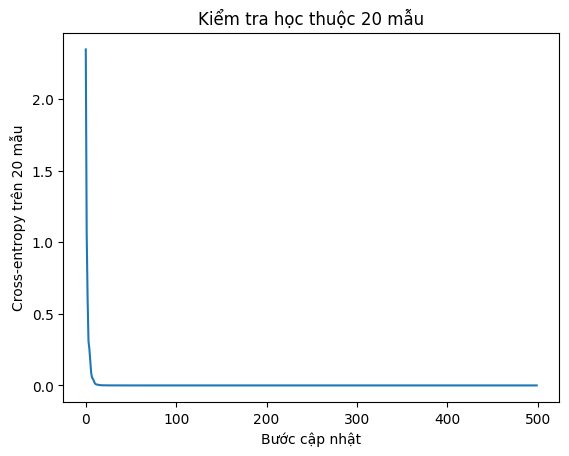

In [3]:
# Cần chạy Part 0 trước để có data và device.
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print("Số tham số:", count_params(model))

x_check = torch.randn(8, 54, device=device)
h = x_check
for layer in model.net:
    h = layer(h)
    print(type(layer).__name__, tuple(h.shape))
assert h.shape == (8, 7)

model.eval()
with torch.no_grad():
    initial_loss = F.cross_entropy(model(data["X_val"]), data["y_val"]).item()
print(f"Loss bước 0: {initial_loss:.4f}; ln(7) = {np.log(7):.4f}")

# Kiểm tra gradient trên một lô thực, trước bước tối ưu đầu tiên.
model.train()
model.zero_grad(set_to_none=True)
loss = F.cross_entropy(model(data["X_tr"][:512]), data["y_tr"][:512])
loss.backward()
for name, parameter in model.named_parameters():
    norm = None if parameter.grad is None else parameter.grad.norm().item()
    print(f"{name}: grad_norm={norm}")
    assert norm is not None and norm > 0

# Mô hình mới, không dropout: học thuộc 20 mẫu để kiểm tra vòng backward/update.
torch.manual_seed(42)
tiny_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
x_small, y_small = data["X_tr"][:20], data["y_tr"][:20]
tiny_optimizer = torch.optim.Adam(tiny_model.parameters(), lr=0.01)
tiny_losses = []
for step in range(500):
    tiny_optimizer.zero_grad(set_to_none=True)
    tiny_loss = F.cross_entropy(tiny_model(x_small), y_small)
    tiny_loss.backward()
    tiny_optimizer.step()
    tiny_losses.append(tiny_loss.item())
tiny_model.eval()
with torch.no_grad():
    tiny_accuracy = (tiny_model(x_small).argmax(dim=1) == y_small).float().mean().item()
print(f"20 mẫu: loss={tiny_losses[-1]:.6f}, accuracy={tiny_accuracy:.1%}")
assert tiny_accuracy == 1.0 and tiny_losses[-1] < 0.01
plt.plot(tiny_losses)
plt.xlabel("Bước cập nhật")
plt.ylabel("Cross-entropy trên 20 mẫu")
plt.title("Kiểm tra học thuộc 20 mẫu")
plt.show()

**Nhận xét Part 1:** M-base có 47.879 tham số và logits `(8, 7)`. Loss bước 0 đo được 2,3776, cao hơn ln 7 = 1,9459; He tạo logits ban đầu chưa đồng đều nên ln 7 chỉ là mốc tham khảo. Tất cả tham số có gradient khác 0. Mô hình học thuộc 20 mẫu với loss khoảng 0,000001 và accuracy 100%.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [4]:
# Tìm lr nhanh trên val; các lần dò 3 epoch không được tính là baseline chính.
lr_trials = []
for lr in (0.01, 0.03, 0.1):
    trial = run_experiment({**DEFAULT_CFG, "exp_id": f"lr-probe-{lr}", "lr": lr, "epochs": 3}, data)
    lr_trials.append((lr, trial["summary"]["val_macro_f1"]))
print("Dò lr (3 epoch, val macro-F1):", lr_trials)
chosen_lr = max(lr_trials, key=lambda item: item[1])[0]
cfg = {**DEFAULT_CFG, "lr": chosen_lr}
print("Baseline lr đã chọn bằng val:", chosen_lr)

baseline_results = []
for seed in (1, 2, 3):
    exp_id = f"base-s{seed}"
    result = run_experiment({**cfg, "seed": seed, "exp_id": exp_id}, data)
    baseline_results.append(result)
    save_result(result, f"{OUT_DIR}/results")
    plot_run(result, f"{OUT_DIR}/figures/{exp_id}.png")
    print(exp_id, result["summary"])
scores = np.array([r["summary"]["val_macro_f1"] for r in baseline_results])
accuracies = np.array([r["summary"]["val_acc"] for r in baseline_results])
noise_threshold = 2 * scores.std(ddof=1)
print(f"Val macro-F1: {scores.mean():.4f} ± {scores.std(ddof=1):.4f}; 2σ={noise_threshold:.4f}")
print(f"Val accuracy: {accuracies.mean():.4f} ± {accuracies.std(ddof=1):.4f}")

lr-probe-0.01 epoch 1: val_loss=0.5840 val_macro_f1=0.5075
lr-probe-0.01 epoch 2: val_loss=0.5283 val_macro_f1=0.5749
lr-probe-0.01 epoch 3: val_loss=0.4945 val_macro_f1=0.6170
lr-probe-0.03 epoch 1: val_loss=0.5101 val_macro_f1=0.6032
lr-probe-0.03 epoch 2: val_loss=0.4572 val_macro_f1=0.6486
lr-probe-0.03 epoch 3: val_loss=0.4215 val_macro_f1=0.6807
lr-probe-0.1 epoch 1: val_loss=0.4618 val_macro_f1=0.6557
lr-probe-0.1 epoch 2: val_loss=0.4113 val_macro_f1=0.7019
lr-probe-0.1 epoch 3: val_loss=0.3755 val_macro_f1=0.7169
Dò lr (3 epoch, val macro-F1): [(0.01, 0.6170160171702646), (0.03, 0.6806561106048089), (0.1, 0.7168729964082704)]
Baseline lr đã chọn bằng val: 0.1
base-s1 epoch 1: val_loss=0.4618 val_macro_f1=0.6557
base-s1 epoch 2: val_loss=0.4113 val_macro_f1=0.7019
base-s1 epoch 3: val_loss=0.3755 val_macro_f1=0.7169
base-s1 epoch 4: val_loss=0.3447 val_macro_f1=0.7474
base-s1 epoch 5: val_loss=0.3261 val_macro_f1=0.7751
base-s1 epoch 6: val_loss=0.3609 val_macro_f1=0.7829
base-

**Nhận xét baseline:** Chọn lr=0,1 từ ba giá trị dò trên val. Ba seed cho val macro-F1 0,8591 / 0,8541 / 0,8606; trung bình 0,8579 ± 0,0034, ngưỡng 2σ=0,0068. Val accuracy trung bình 0,9113, vượt mốc đoán lớp đa số 0,4876. Val loss nhìn chung giảm đến epoch 20, còn dao động giữa các epoch; train loss cuối thấp hơn val loss khoảng 0,02.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Dự đoán trước khi chạy
- `loss-mse`: MSE trên logits và one-hot sẽ hội tụ chậm hơn CE vì gradient khác nhau. So macro-F1, không so trị số loss.
- `opt-adam-*`: Adam có thể đạt macro-F1 cao sớm hơn SGD; cần thử ít nhất hai lr riêng của Adam.
- `batch-256`: batch nhỏ hơn tăng số bước cập nhật mỗi epoch và có thể cải thiện tốc độ hội tụ, nhưng thời gian mỗi epoch tăng.
- `drop-02`: dropout có thể giảm khoảng cách train–val nếu đang quá khớp; nếu chưa quá khớp, điểm val có thể giảm.
- `clip-1`: ở lr hiện tại, clipping chỉ giúp nếu grad_norm thường vượt 1.
- `init-xavier`: Xavier có thể làm kích hoạt ReLU nhỏ hơn He và thay đổi tốc độ hội tụ.
- Mixed precision: bỏ qua vì môi trường hiện tại chạy CPU; không giả vờ có số đo GPU.

In [5]:
# Giữ seed=1, 20 epoch. Riêng Adam đổi cả optimizer và lr để so ở lr phù hợp của từng bộ.
experiments = [
    {"exp_id": "loss-mse", "group": "loss", "description": "MSE thay CE", "loss": "mse"},
    {"exp_id": "opt-adam-1e-3", "group": "optimizer", "description": "Adam lr=0.001", "optimizer": "adam", "lr": 0.001},
    {"exp_id": "opt-adam-3e-3", "group": "optimizer", "description": "Adam lr=0.003", "optimizer": "adam", "lr": 0.003},
    {"exp_id": "batch-256", "group": "hparam", "description": "Batch 256 thay 512", "batch": 256},
    {"exp_id": "drop-02", "group": "dropout", "description": "Dropout 0.2", "dropout": 0.2},
    {"exp_id": "clip-1", "group": "clipping", "description": "Clip norm 1.0", "clip_norm": 1.0},
    {"exp_id": "init-xavier", "group": "init", "description": "Xavier thay He", "init": "xavier"},
]
experiment_results = []
baseline_f1 = baseline_results[0]["summary"]["val_macro_f1"]
for changes in experiments:
    exp_cfg = {**cfg, "seed": 1, **changes}
    result = run_experiment(exp_cfg, data)
    experiment_results.append(result)
    save_result(result, f"{OUT_DIR}/results")
    plot_run(result, f"{OUT_DIR}/figures/{exp_cfg['exp_id']}.png")
    score = result["summary"]["val_macro_f1"]
    print(f"{exp_cfg['exp_id']}: val macro-F1={score:.4f}; Δ với base-s1={score-baseline_f1:+.4f}; 2σ={noise_threshold:.4f}")

loss-mse epoch 1: val_loss=0.0489 val_macro_f1=0.4530
loss-mse epoch 2: val_loss=0.0447 val_macro_f1=0.5126
loss-mse epoch 3: val_loss=0.0423 val_macro_f1=0.5526
loss-mse epoch 4: val_loss=0.0403 val_macro_f1=0.5892
loss-mse epoch 5: val_loss=0.0386 val_macro_f1=0.6352
loss-mse epoch 6: val_loss=0.0377 val_macro_f1=0.6384
loss-mse epoch 7: val_loss=0.0365 val_macro_f1=0.6573
loss-mse epoch 8: val_loss=0.0357 val_macro_f1=0.6683
loss-mse epoch 9: val_loss=0.0343 val_macro_f1=0.6704
loss-mse epoch 10: val_loss=0.0337 val_macro_f1=0.6875
loss-mse epoch 11: val_loss=0.0333 val_macro_f1=0.6959
loss-mse epoch 12: val_loss=0.0326 val_macro_f1=0.6980
loss-mse epoch 13: val_loss=0.0320 val_macro_f1=0.7111
loss-mse epoch 14: val_loss=0.0324 val_macro_f1=0.7174
loss-mse epoch 15: val_loss=0.0316 val_macro_f1=0.7207
loss-mse epoch 16: val_loss=0.0310 val_macro_f1=0.7170
loss-mse epoch 17: val_loss=0.0303 val_macro_f1=0.7296
loss-mse epoch 18: val_loss=0.0297 val_macro_f1=0.7315
loss-mse epoch 19: 

**Đối chiếu sau khi chạy:** `loss-mse` đạt val F1 0,7388, kém CE 0,1203; không so giá trị loss giữa hai thang đo. `opt-adam-3e-3` đạt 0,8742, hơn `base-s1` 0,0152 và vượt 2σ=0,0068. Adam lr=0,001 chỉ đạt 0,8496, cho thấy cần chỉnh lr riêng. `batch-256` đạt 0,8622, hơn baseline 0,0031, chưa vượt nhiễu; batch nhỏ cũng làm số bước cập nhật mỗi epoch tăng. `drop-02` giảm còn 0,8209, phù hợp với việc baseline chưa quá khớp nặng. `clip-1` đạt 0,8533 và `init-xavier` 0,8544, chênh lệch với baseline chưa vượt nhiễu.

In [6]:
# Ảnh so sánh các nhóm có ít nhất hai cấu hình.
plot_compare([baseline_results[0]] + [r for r in experiment_results if r['cfg']['group'] == 'optimizer'],
             'val_macro_f1', f"{OUT_DIR}/figures/compare_optimizer.png", 'Optimizer: val macro-F1')
plot_compare([baseline_results[0]] + [r for r in experiment_results if r['cfg']['group'] == 'dropout'],
             'val_loss', f"{OUT_DIR}/figures/compare_dropout.png", 'Dropout: val loss')

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [7]:
# Nạp lại phần Part 4 vừa được hoàn thiện, giữ nguyên kết quả train trong RAM.
importlib.reload(train_module)
final_eval = train_module.final_eval
# Chọn trước khi xem eval: opt-adam-3e-3 có val macro-F1 cao nhất (0.8742).
final_result = next(r for r in experiment_results if r['cfg']['exp_id'] == 'opt-adam-3e-3')
baseline_result = baseline_results[0]
baseline_pred = f"{OUT_DIR}/results/baseline_predictions_eval.csv"
final_pred = f"{OUT_DIR}/predictions_eval.csv"
final_eval(baseline_result['cfg'], baseline_result, data, baseline_pred)
final_eval(final_result['cfg'], final_result, data, final_pred)
for pred_path, out_path in ((baseline_pred, f"{OUT_DIR}/results/baseline_eval.json"),
                            (final_pred, f"{OUT_DIR}/eval_result.json")):
    subprocess.run([sys.executable, 'scripts/evaluate.py', '--pred', str(Path(pred_path).resolve()),
                    '--out', str(Path(out_path).resolve())], cwd=REPO_ROOT, check=True)
baseline_eval = json.loads(Path(f"{OUT_DIR}/results/baseline_eval.json").read_text(encoding='utf-8'))
final_eval_scores = json.loads(Path(f"{OUT_DIR}/eval_result.json").read_text(encoding='utf-8'))
print('Baseline eval macro-F1:', baseline_eval['macro_f1'])
print('Final eval macro-F1:', final_eval_scores['macro_f1'])

Baseline eval macro-F1: 0.8614462038646541
Final eval macro-F1: 0.8793709922469725


Lớp 0: support=42368, precision=0.9262, recall=0.8976, F1=0.9117
Lớp 1: support=56661, precision=0.9161, recall=0.9444, F1=0.9300
Lớp 2: support=7151, precision=0.9158, recall=0.9155, F1=0.9157
Lớp 3: support=549, precision=0.8040, recall=0.8889, F1=0.8443
Lớp 4: support=1899, precision=0.8666, recall=0.7083, F1=0.7795
Lớp 5: support=3473, precision=0.8699, recall=0.8241, F1=0.8464
Lớp 6: support=4102, precision=0.9243, recall=0.9320, F1=0.9281


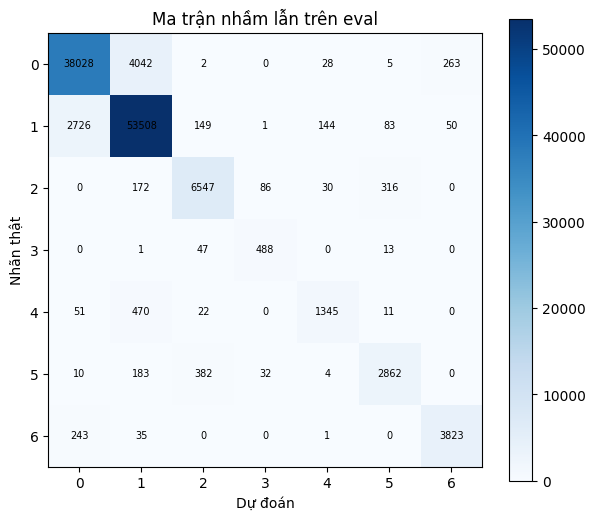

In [8]:
for row in final_eval_scores['per_class']:
    print(f"Lớp {row['cls']}: support={row['support']}, precision={row['precision']:.4f}, recall={row['recall']:.4f}, F1={row['f1']:.4f}")
cm = np.array(final_eval_scores['confusion_matrix'])
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(cm, cmap='Blues')
fig.colorbar(image, ax=ax)
ax.set(xlabel='Dự đoán', ylabel='Nhãn thật', title='Ma trận nhầm lẫn trên eval')
ax.set_xticks(range(7)); ax.set_yticks(range(7))
for i in range(7):
    for j in range(7):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=7)
fig.savefig(f"{OUT_DIR}/figures/confusion_eval.png", dpi=150, bbox_inches='tight')
plt.show()

**Phân tích lỗi:** Lớp 4 (Aspen) khó nhất: support 1.899, recall 0,7083, F1 0,7795; 470 mẫu bị nhầm thành lớp 1. Lớp 4 chỉ chiếm khoảng 1,6% dữ liệu eval, nên mất cân bằng lớp có thể góp phần làm recall thấp. Ma trận nhầm lẫn cũng cho thấy hai lớp đông mẫu 0 và 1 nhầm lẫn nhiều theo số tuyệt đối.

In [9]:
importlib.reload(results_module)
load_results, to_row, write_xlsx = results_module.load_results, results_module.to_row, results_module.write_xlsx
all_results = load_results(f"{OUT_DIR}/results")
rows = []
for result in all_results:
    exp_id = result['cfg']['exp_id']
    eval_scores = baseline_eval if exp_id == 'base-s1' else final_eval_scores if exp_id == 'opt-adam-3e-3' else None
    rows.append(to_row(result, eval_scores=eval_scores))
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
print(f"Đã ghi {len(rows)} dòng vào {OUT_DIR}/experiments.xlsx")

Đã ghi 10 dòng vào ../experiments.xlsx
